<a href="https://colab.research.google.com/github/guzik1234/DataScienceCwiczenia/blob/main/python_pandas/Tabele_Przestawne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()


In [26]:
tit = sns.load_dataset('titanic')
tit

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: xlabel='sex,survived'>

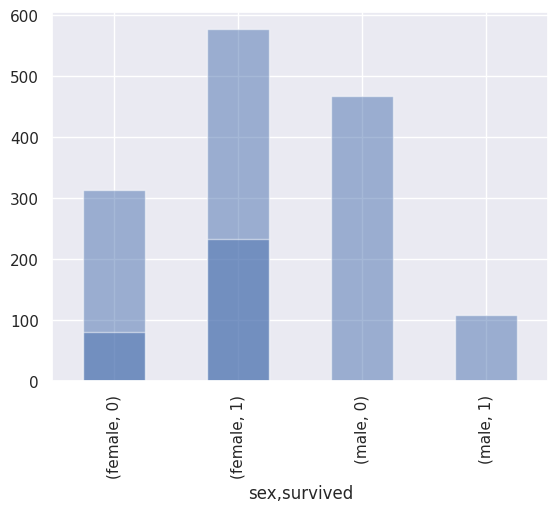

In [7]:
tit.groupby('sex').size().plot(kind='bar', alpha=0.5)
tit.groupby(['sex', 'survived']).size().plot(kind='bar', alpha=0.5)

/tmp/ipykernel_45667/1222556679.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tit.groupby('class').size().plot(kind='bar', alpha=0.5)
/tmp/ipykernel_45667/1222556679.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tit.groupby('class')['survived'].mean().plot(kind='bar', alpha=0.5)


<Axes: xlabel='class'>

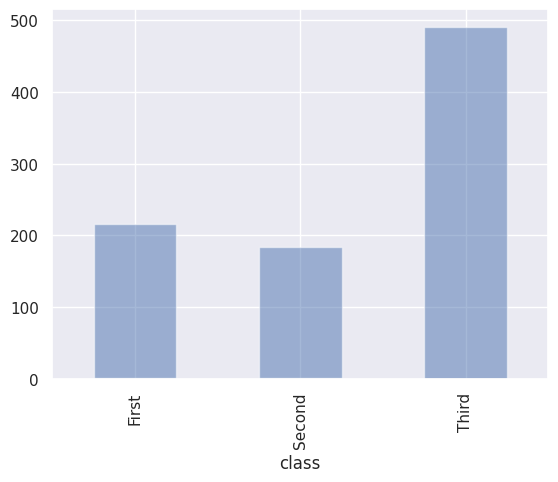

In [11]:
tit.groupby('class').size().plot(kind='bar', alpha=0.5)


/tmp/ipykernel_45667/960333485.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tit.groupby('class')['survived'].mean().plot(kind='bar', alpha=0.5)


<Axes: xlabel='class'>

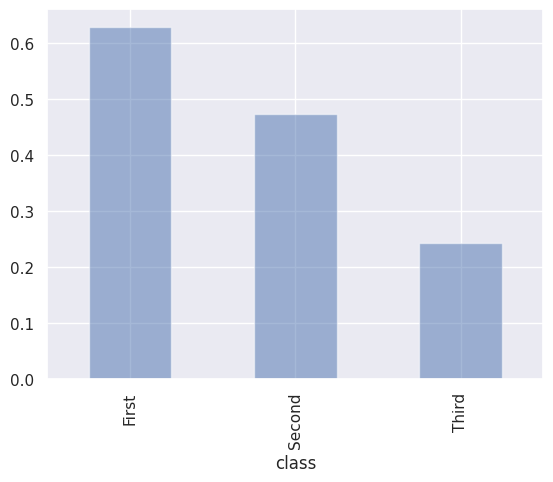

In [12]:
tit.groupby('class')['survived'].mean().plot(kind='bar', alpha=0.5)

In [13]:
pd.pivot_table(data=tit, values='survived', index='sex', columns='class', aggfunc='count')

/tmp/ipykernel_45667/224940398.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data=tit, values='survived', index='sex', columns='class', aggfunc='count')


class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


In [15]:
tit['age_bin'] = pd.cut(x=tit['age'], bins=[0,18,80])

In [17]:
pd.pivot_table(data=tit, values='survived', index='age_bin', columns='class', aggfunc='count')

/tmp/ipykernel_45667/2882520921.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data=tit, values='survived', index='age_bin', columns='class', aggfunc='count')


class,First,Second,Third
age_bin,,,
"(0, 18]",16,29,94
"(18, 80]",170,144,261


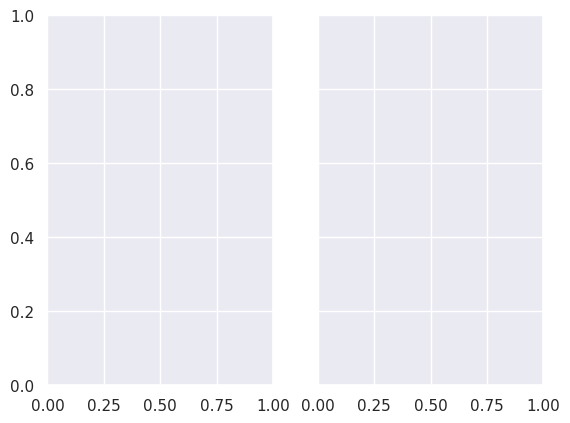

In [18]:
fig, ax = plt.subplots(1,2, sharey=True)

In [20]:
tit.groupby(['sex', 'survived']).size()['male'].plot(ax=ax[0])

<Axes: xlabel='survived'>

In [22]:
r = pd.pivot_table(data=tit, values='survived', index='age_bin', columns='sex', aggfunc='count')

/tmp/ipykernel_45667/2311594315.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  r = pd.pivot_table(data=tit, values='survived', index='age_bin', columns='sex', aggfunc='count')


array([[<Axes: title={'center': 'female'}, xlabel='age_bin'>,
        <Axes: title={'center': 'male'}, xlabel='age_bin'>]], dtype=object)

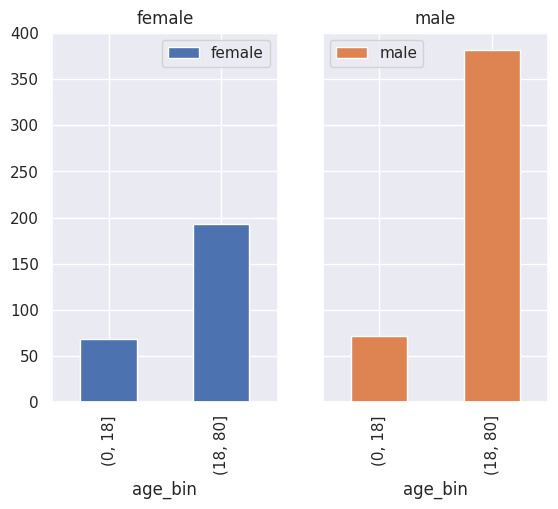

In [24]:

r.plot(subplots=True, kind='bar', sharey=True, layout=(1,2))

In [27]:
pd.pivot_table(data=tit, index='sex', columns='class', aggfunc={'survived': sum, 'fare': 'mean', 'age': 'mean'})

/tmp/ipykernel_45667/3972334422.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data=tit, index='sex', columns='class', aggfunc={'survived': sum, 'fare': 'mean', 'age': 'mean'})
/tmp/ipykernel_45667/3972334422.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pd.pivot_table(data=tit, index='sex', columns='class', aggfunc={'survived': sum, 'fare': 'mean', 'age': 'mean'})


age                              fare                        \
class       First     Second      Third       First     Second      Third   
sex                                                                         
female  34.611765  28.722973  21.750000  106.125798  21.970121  16.118810   
male    41.281386  30.740707  26.507589   67.226127  19.741782  12.661633   

       survived               
class     First Second Third  
sex                           
female       91     70    72  
male         45     17    47

In [28]:
url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz')

In [33]:
metro = pd.read_csv(url, compression='gzip', index_col='date_time', parse_dates=True)
metro.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume
date_time,,,,,,,,
2012-10-02 09:00:00,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
2012-10-02 10:00:00,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2012-10-02 11:00:00,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
2012-10-02 12:00:00,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
2012-10-02 13:00:00,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [34]:
metro = metro.loc['2016-01-01':]

<Axes: xlabel='date_time'>

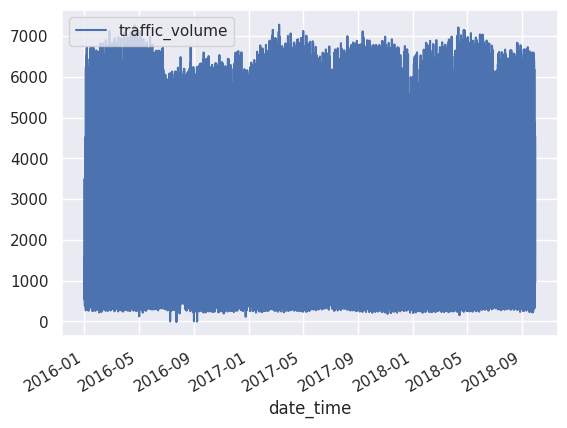

In [35]:
traffic= metro.iloc[:, -1:]
traffic.plot()

/tmp/ipykernel_45667/2904799285.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tr = traffic.resample("M").sum()


<Axes: xlabel='date_time'>

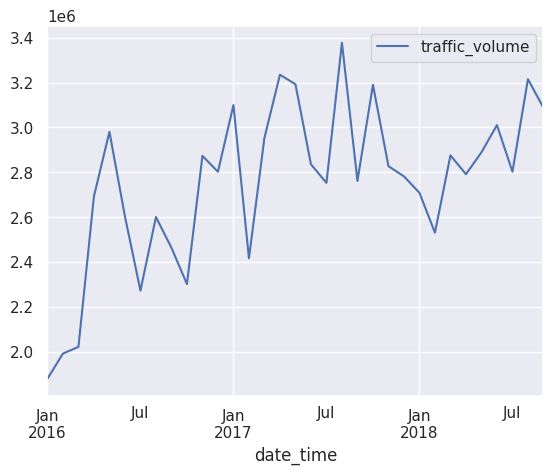

In [37]:
tr = traffic.resample("M").sum()
tr.plot()

<Axes: xlabel='weather_main'>

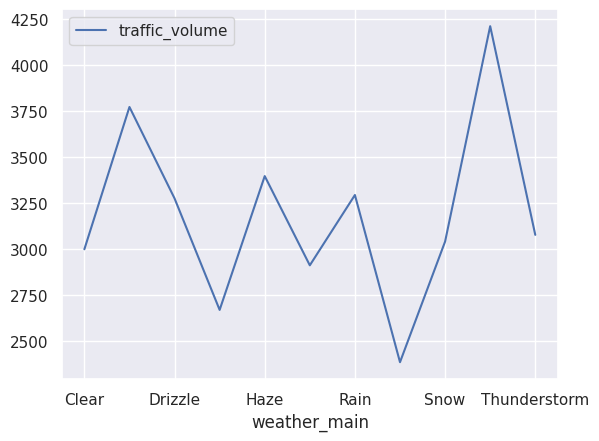

In [40]:
metro.pivot_table(values='traffic_volume', aggfunc='mean', index='weather_main').plot()

In [41]:
tips =sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [43]:
tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='mean')

/tmp/ipykernel_45667/3533193633.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='mean')


day,Thur,Fri,Sat,Sun
sex,,,,
Male,2.980333,2.693000,3.083898,3.220345
Female,2.575625,2.781111,2.801786,3.367222


In [44]:
pv = tips.pivot_table(values=['tip', 'total_bill'], index='sex', columns='day', aggfunc='mean')
pv

/tmp/ipykernel_45667/2627468713.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = tips.pivot_table(values=['tip', 'total_bill'], index='sex', columns='day', aggfunc='mean')


tip                               total_bill             \
day         Thur       Fri       Sat       Sun       Thur        Fri   
sex                                                                    
Male    2.980333  2.693000  3.083898  3.220345  18.714667  19.857000   
Female  2.575625  2.781111  2.801786  3.367222  16.715312  14.145556   

                              
day           Sat        Sun  
sex                           
Male    20.802542  21.887241  
Female  19.680357  19.872222

In [45]:
tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='max')

/tmp/ipykernel_45667/3999217465.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='max')


day,Thur,Fri,Sat,Sun
sex,,,,
Male,6.70,4.73,10.0,6.5
Female,5.17,4.30,6.5,5.2


In [46]:
tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='min')

/tmp/ipykernel_45667/1349472051.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='min')


day,Thur,Fri,Sat,Sun
sex,,,,
Male,1.44,1.5,1.0,1.32
Female,1.25,1.0,1.0,1.01


In [48]:
tips.pivot_table(values='tip', index='sex', columns=['smoker', 'day'], aggfunc='min')

/tmp/ipykernel_45667/3129662289.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='sex', columns=['smoker', 'day'], aggfunc='min')


smoker  Yes                   No                 
day    Thur  Fri  Sat  Sun  Thur  Fri   Sat   Sun
sex                                              
Male    2.0  1.5  1.0  1.5  1.44  1.5  1.25  1.32
Female  2.0  1.0  1.0  3.0  1.25  3.0  1.00  1.01

/tmp/ipykernel_45667/1106067422.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)


<Axes: xlabel='sex'>

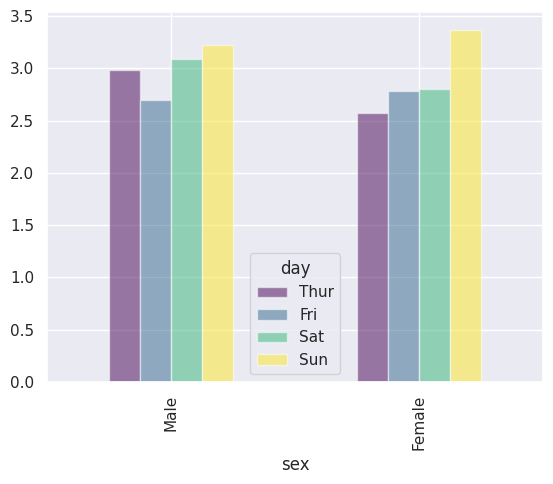

In [54]:
tips.pivot_table(values='tip', index='sex', columns='day', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)

/tmp/ipykernel_45667/3875311785.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='total_bill', index='sex', columns='day', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)


<Axes: xlabel='sex'>

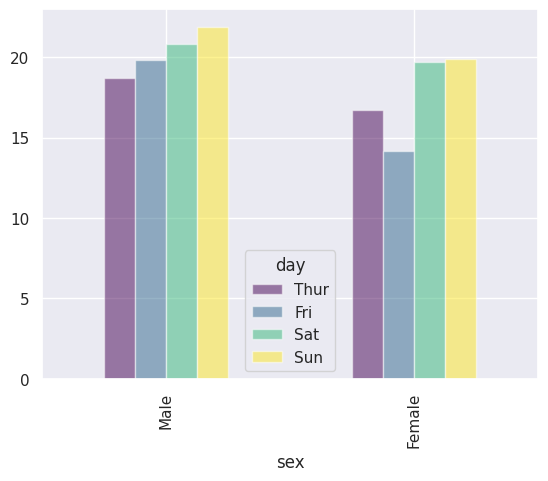

In [55]:
tips.pivot_table(values='total_bill', index='sex', columns='day', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)

/tmp/ipykernel_45667/2035671343.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='total_bill', index='day', columns='size', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)


<Axes: xlabel='day'>

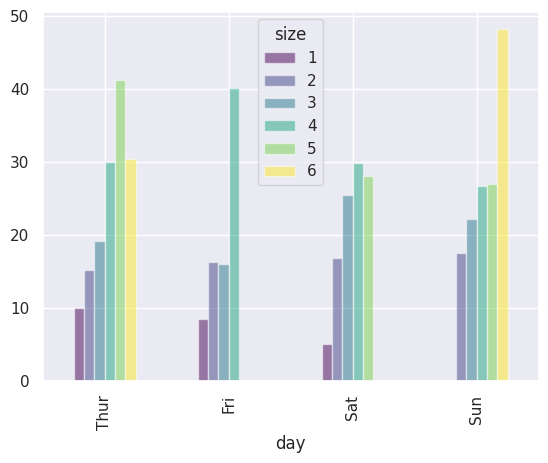

In [56]:
tips.pivot_table(values='total_bill', index='day', columns='size', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)

/tmp/ipykernel_45667/1984647146.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(values='tip', index='time', columns='size', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)


<Axes: xlabel='time'>

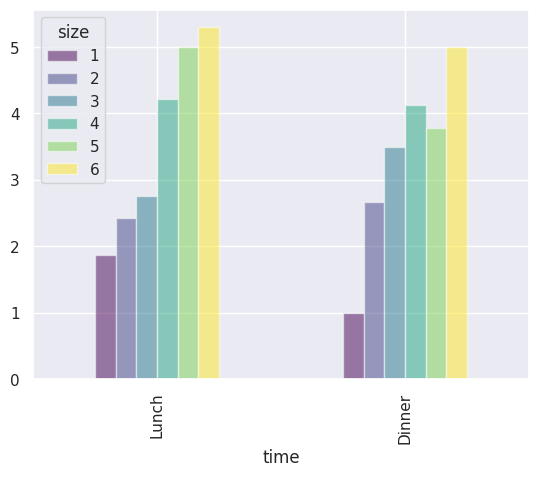

In [58]:
tips.pivot_table(values='tip', index='time', columns='size', aggfunc='mean').plot(kind='bar', cmap='viridis', alpha=0.5)

In [59]:
vals = tips[['total_bill', 'tip']]
vals.corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000
